# Exploración del Dataset Próstata - NER Biomédico

**Objetivo**: Analizar el dataset de entidades nombradas (NER) sobre textos clínicos de cáncer de próstata.

**Dataset**: Próstata (formato BIO)
- **Entrenamiento**: `training.bio`
- **Validación**: `validation_cleaned.bio`
- **Prueba**: `testing_cleaned.bio`

**Entidades clínicas**:
1. EDAD - Edad del paciente
2. BIOMARCADOR - PSA, marcadores biológicos
3. CANCER - Tipos de cáncer
4. GLEASON - Score de Gleason
5. TNM - Clasificación TNM
6. TRATAMIENTO - Tratamientos médicos
7. MEDICAMENTO - Medicamentos
8. DOSIS - Dosis de medicamentos
9. CIRUGIA - Procedimientos quirúrgicos
10. FECHA - Fechas de eventos médicos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Carga del Dataset

El dataset está en formato BIO:
- Una palabra y su etiqueta por línea (separadas por tabulador)
- Líneas vacías separan oraciones

In [2]:
def load_bio_file(filepath):
    """
    Carga un archivo en formato BIO.
    Retorna lista de oraciones, donde cada oración es lista de tuplas (token, label).
    """
    sentences = []
    current_sentence = []
    
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            
            if line == '':
                if current_sentence:
                    sentences.append(current_sentence)
                    current_sentence = []
            else:
                parts = line.split('\t')
                if len(parts) == 2:
                    token, label = parts
                    current_sentence.append((token, label))
        
        # Agregar última oración si existe
        if current_sentence:
            sentences.append(current_sentence)
    
    return sentences

# Rutas a los datasets
base_path = Path('../datasets-taller/datasets-taller/prostata')
train_path = base_path / 'training.bio'
val_path = base_path / 'validation_cleaned.bio'
test_path = base_path / 'testing_cleaned.bio'

# Cargar datasets
train_sentences = load_bio_file(train_path)
val_sentences = load_bio_file(val_path)
test_sentences = load_bio_file(test_path)

print(f"📊 Oraciones por conjunto:")
print(f"  Entrenamiento: {len(train_sentences):,}")
print(f"  Validación: {len(val_sentences):,}")
print(f"  Prueba: {len(test_sentences):,}")
print(f"  Total: {len(train_sentences) + len(val_sentences) + len(test_sentences):,}")

📊 Oraciones por conjunto:
  Entrenamiento: 3,106
  Validación: 929
  Prueba: 991
  Total: 5,026


## 2. Estadísticas Básicas

In [3]:
def get_dataset_stats(sentences, name):
    """
    Calcula estadísticas de un conjunto de datos.
    """
    all_tokens = [token for sent in sentences for token, label in sent]
    all_labels = [label for sent in sentences for token, label in sent]
    sent_lengths = [len(sent) for sent in sentences]
    
    stats = {
        'Conjunto': name,
        'Oraciones': len(sentences),
        'Tokens': len(all_tokens),
        'Tokens únicos': len(set(all_tokens)),
        'Etiquetas únicas': len(set(all_labels)),
        'Long. promedio': np.mean(sent_lengths),
        'Long. mediana': np.median(sent_lengths),
        'Long. máxima': max(sent_lengths),
        'Long. mínima': min(sent_lengths)
    }
    return stats

# Calcular estadísticas
stats_list = [
    get_dataset_stats(train_sentences, 'Entrenamiento'),
    get_dataset_stats(val_sentences, 'Validación'),
    get_dataset_stats(test_sentences, 'Prueba')
]

stats_df = pd.DataFrame(stats_list)
print("\n📈 Estadísticas del Dataset Próstata:\n")
display(stats_df.round(2))


📈 Estadísticas del Dataset Próstata:



,Conjunto,Oraciones,Tokens,Tokens únicos,Etiquetas únicas,Long. promedio,Long. mediana,Long. máxima,Long. mínima
0,Entrenamiento,3106,67934,4604,21,21.87,15.0,172,2
1,Validación,929,16803,2371,22,18.09,13.0,101,2
2,Prueba,991,20861,2507,22,21.05,17.0,126,1


## 3. Análisis de Etiquetas

In [4]:
# Extraer todas las etiquetas
train_labels = [label for sent in train_sentences for token, label in sent]
val_labels = [label for sent in val_sentences for token, label in sent]
test_labels = [label for sent in test_sentences for token, label in sent]

# Contar frecuencias
train_label_counts = Counter(train_labels)
val_label_counts = Counter(val_labels)
test_label_counts = Counter(test_labels)

# Crear DataFrame
all_labels = sorted(set(train_labels + val_labels + test_labels))
label_dist = pd.DataFrame({
    'Etiqueta': all_labels,
    'Entrenamiento': [train_label_counts[label] for label in all_labels],
    'Validación': [val_label_counts[label] for label in all_labels],
    'Prueba': [test_label_counts[label] for label in all_labels]
})

label_dist['Total'] = label_dist['Entrenamiento'] + label_dist['Validación'] + label_dist['Prueba']
label_dist['% Train'] = (label_dist['Entrenamiento'] / label_dist['Entrenamiento'].sum() * 100).round(2)

print("\n🏷️ Distribución de Etiquetas:\n")
display(label_dist.sort_values('Total', ascending=False))


🏷️ Distribución de Etiquetas:



,Etiqueta,Entrenamiento,Validación,Prueba,Total,% Train
22,O,52701,13576,16621,82898,77.58
13,I-CANCER,2131,519,647,3297,3.14
17,I-FECHA,1365,411,478,2254,2.01
7,B-FECHA,1262,319,401,1982,1.86
3,B-CANCER,1207,296,364,1867,1.78
15,I-DOSIS,1264,110,239,1613,1.86
11,B-TRATAMIENTO,1130,158,250,1538,1.66
18,I-GLEASON,984,225,262,1471,1.45
12,I-BIOMARCADOR,874,170,287,1331,1.29
2,B-BIOMARCADOR,895,197,207,1299,1.32


In [5]:
# Agrupar por tipo de entidad (sin B-/I-)
def get_entity_type(label):
    if label == 'O':
        return 'O'
    return label.split('-')[1] if '-' in label else label

train_entities = [get_entity_type(label) for label in train_labels]
entity_counts = Counter(train_entities)

# Crear DataFrame de tipos de entidad
entity_df = pd.DataFrame([
    {'Tipo Entidad': entity, 'Frecuencia': count, 'Porcentaje': count/len(train_entities)*100}
    for entity, count in entity_counts.most_common()
])

print("\n🔬 Tipos de Entidades Clínicas (Training):\n")
display(entity_df.round(2))


🔬 Tipos de Entidades Clínicas (Training):



,Tipo Entidad,Frecuencia,Porcentaje
0,O,52701,77.58
1,CANCER,3338,4.91
2,FECHA,2627,3.87
3,DOSIS,2049,3.02
4,TRATAMIENTO,1884,2.77
5,BIOMARCADOR,1769,2.60
6,GLEASON,1582,2.33
7,CIRUGIA,585,0.86
8,MEDICAMENTO,538,0.79
9,EDAD,486,0.72


## 4. Visualización de Distribuciones

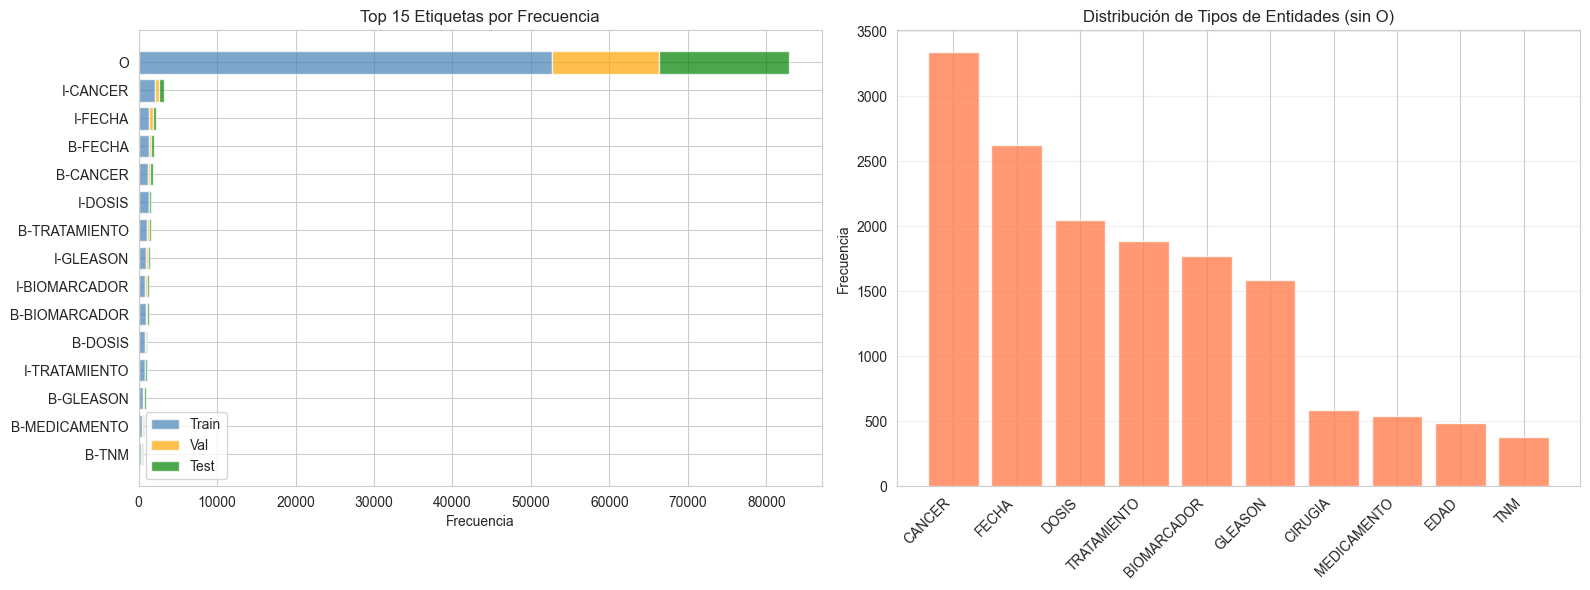

In [6]:
# Gráfico de distribución de etiquetas (Top 15)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 15 etiquetas más frecuentes
top_labels = label_dist.nlargest(15, 'Total')

axes[0].barh(top_labels['Etiqueta'], top_labels['Entrenamiento'], color='steelblue', alpha=0.7, label='Train')
axes[0].barh(top_labels['Etiqueta'], top_labels['Validación'], left=top_labels['Entrenamiento'], 
             color='orange', alpha=0.7, label='Val')
axes[0].barh(top_labels['Etiqueta'], top_labels['Prueba'], 
             left=top_labels['Entrenamiento']+top_labels['Validación'], 
             color='green', alpha=0.7, label='Test')
axes[0].set_xlabel('Frecuencia')
axes[0].set_title('Top 15 Etiquetas por Frecuencia')
axes[0].legend()
axes[0].invert_yaxis()

# Distribución de tipos de entidad (sin O)
entity_df_no_o = entity_df[entity_df['Tipo Entidad'] != 'O']
axes[1].bar(range(len(entity_df_no_o)), entity_df_no_o['Frecuencia'], color='coral', alpha=0.8)
axes[1].set_xticks(range(len(entity_df_no_o)))
axes[1].set_xticklabels(entity_df_no_o['Tipo Entidad'], rotation=45, ha='right')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Tipos de Entidades (sin O)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

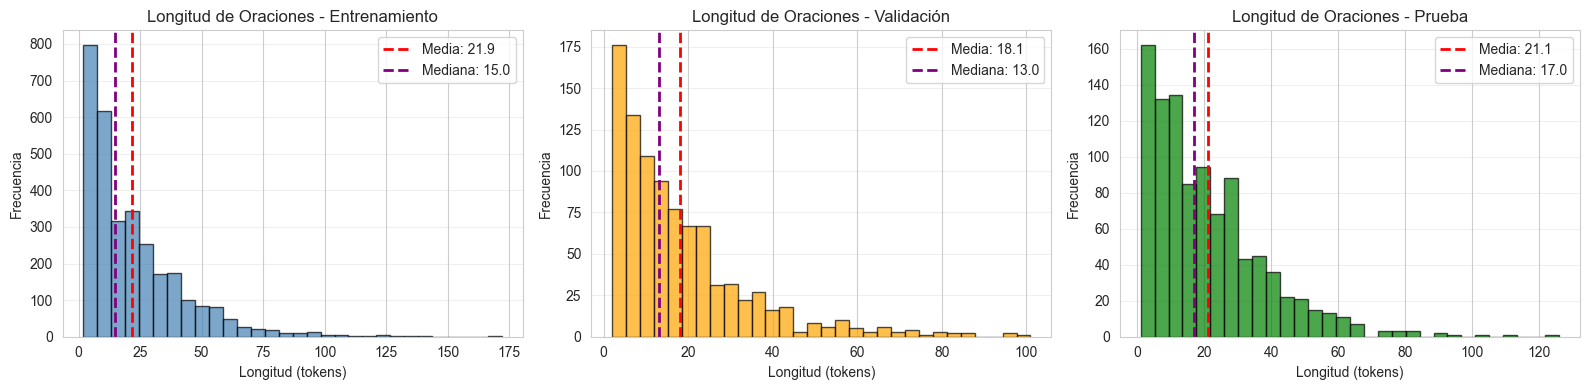


📏 Estadísticas de longitud de oraciones:
  Train - Media: 21.87, Mediana: 15, Max: 172
  Val   - Media: 18.09, Mediana: 13, Max: 101
  Test  - Media: 21.05, Mediana: 17, Max: 126


In [7]:
# Distribución de longitudes de oraciones
train_lengths = [len(sent) for sent in train_sentences]
val_lengths = [len(sent) for sent in val_sentences]
test_lengths = [len(sent) for sent in test_sentences]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, lengths, name, color in zip(axes, 
                                      [train_lengths, val_lengths, test_lengths],
                                      ['Entrenamiento', 'Validación', 'Prueba'],
                                      ['steelblue', 'orange', 'green']):
    ax.hist(lengths, bins=30, color=color, alpha=0.7, edgecolor='black')
    ax.axvline(np.mean(lengths), color='red', linestyle='--', linewidth=2, label=f'Media: {np.mean(lengths):.1f}')
    ax.axvline(np.median(lengths), color='purple', linestyle='--', linewidth=2, label=f'Mediana: {np.median(lengths):.1f}')
    ax.set_xlabel('Longitud (tokens)')
    ax.set_ylabel('Frecuencia')
    ax.set_title(f'Longitud de Oraciones - {name}')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📏 Estadísticas de longitud de oraciones:")
print(f"  Train - Media: {np.mean(train_lengths):.2f}, Mediana: {np.median(train_lengths):.0f}, Max: {max(train_lengths)}")
print(f"  Val   - Media: {np.mean(val_lengths):.2f}, Mediana: {np.median(val_lengths):.0f}, Max: {max(val_lengths)}")
print(f"  Test  - Media: {np.mean(test_lengths):.2f}, Mediana: {np.median(test_lengths):.0f}, Max: {max(test_lengths)}")

## 5. Análisis de Entidades

In [8]:
def extract_entities(sentences):
    """
    Extrae entidades completas de las oraciones.
    Retorna lista de tuplas (texto_entidad, tipo_entidad).
    """
    entities = []
    
    for sentence in sentences:
        current_entity = []
        current_type = None
        
        for token, label in sentence:
            if label.startswith('B-'):
                # Guardar entidad anterior si existe
                if current_entity:
                    entities.append((' '.join(current_entity), current_type))
                # Iniciar nueva entidad
                current_entity = [token]
                current_type = label[2:]
            elif label.startswith('I-') and current_entity:
                # Continuar entidad actual
                current_entity.append(token)
            else:
                # Guardar entidad si existe y reiniciar
                if current_entity:
                    entities.append((' '.join(current_entity), current_type))
                    current_entity = []
                    current_type = None
        
        # Guardar última entidad
        if current_entity:
            entities.append((' '.join(current_entity), current_type))
    
    return entities

# Extraer entidades de entrenamiento
train_entities_list = extract_entities(train_sentences)

print(f"\n🔍 Total de entidades en entrenamiento: {len(train_entities_list):,}")
print(f"\n📝 Ejemplos de entidades por tipo:\n")

# Mostrar ejemplos por tipo
entities_by_type = {}
for text, entity_type in train_entities_list:
    if entity_type not in entities_by_type:
        entities_by_type[entity_type] = []
    entities_by_type[entity_type].append(text)

for entity_type, examples in sorted(entities_by_type.items()):
    print(f"\n{entity_type} ({len(examples)} entidades):")
    # Mostrar 5 ejemplos únicos
    unique_examples = list(set(examples))[:5]
    for example in unique_examples:
        print(f"  • {example}")


🔍 Total de entidades en entrenamiento: 7,215

📝 Ejemplos de entidades por tipo:


BIOMARCADOR (895 entidades):
  • 2.18 ng/ml
  • PSAi 10.53 ng/ml
  • PSA mas alto reportado en HC 8 ng/dl
  • PSA 8 ng/ml
  • PSA en 1,0 ng/ml

CANCER (1207 entidades):
  • oligoprometastasis
  • tumor neuroendocrino metastásico
  • cáncer de próstata, tipo adenocarcinoma acinar
  • metastásico óseo de alto volumen
  • Recaída bioquímica

CIRUGIA (254 entidades):
  • CIRUGIA DE COLON
  • PROSTATECTOMI­A RADICAL
  • cirugía de miembro inferior derecho
  • rtu
  • adenomectomía de próstata

DOSIS (785 entidades):
  • 6600cgy
  • ciclo 4
  • 30 Gy
  • 3 fracciones
  • 4 ciclos

EDAD (246 entidades):
  • 72 años
  • 85 años
  • 65 años
  • 90 años
  • nonagenario

FECHA (1262 entidades):
  • 17 mayo del 2023
  • 11/08/2023
  • 19/12/2023
  • 09/01/2024
  • 18/03/2024

GLEASON (598 entidades):
  • GLEASON 3+3 SCORE 6
  • Gleason 4+5 score 9
  • ISUP 3
  • Gleason isup 3 + 4 7
  • Gleason 4+5 g5

MEDICAMENTO (

## 6. Ejemplos de Oraciones Completas

In [9]:
def display_sentence_with_entities(sentence, idx):
    """
    Muestra una oración con sus entidades resaltadas.
    """
    print(f"\n{'='*80}")
    print(f"Oración {idx}:")
    print('='*80)
    
    # Texto completo
    text = ' '.join([token for token, label in sentence])
    print(f"\nTexto: {text}")
    
    # Entidades encontradas
    entities = extract_entities([sentence])
    if entities:
        print(f"\nEntidades encontradas:")
        for entity_text, entity_type in entities:
            print(f"  • [{entity_type}] {entity_text}")
    else:
        print("\nNo se encontraron entidades.")

# Mostrar ejemplos de oraciones
print("\n📄 Ejemplos de Oraciones Anotadas:\n")
for i in [0, 5, 10]:
    if i < len(train_sentences):
        display_sentence_with_entities(train_sentences[i], i+1)


📄 Ejemplos de Oraciones Anotadas:


Oración 1:

Texto: Paciente de 72 años , con antecedentes médicos de HTA .

Entidades encontradas:
  • [EDAD] 72 años

Oración 6:

Texto: Se cita a control con estudios actualizados RMN de pelvis contrastada , GGO y PSA 7,57 ng/mL PSA en 9,9 ng/dl .

Entidades encontradas:
  • [BIOMARCADOR] PSA 7,57 ng/mL
  • [BIOMARCADOR] PSA en 9,9 ng/dl

Oración 11:

Texto: Por parte de oncología radioterápica nos encontramos con un paciente con cáncer de próstata, tipo adenocarcinoma , Gleason 3+3 , PSA en 9,9 ng/dl 9,9 ng / dl , cT2a ( lesión de 5 mm en lóbulo derecho en RMN de pelvis ) cN0 ( no adenopatías en RMN de pelvis ) M0 ( sin lesiones metastásicas en GGO ) ISUP 1 , grupo de bajo riesgo DINAMICO y grupo de bajo riesgo NCCN , que se beneficia de tratamiento con RT tipo IMRT .

Entidades encontradas:
  • [CANCER] cáncer de próstata, tipo adenocarcinoma
  • [GLEASON] Gleason 3+3
  • [BIOMARCADOR] PSA en 9,9 ng/dl
  • [TNM] cT2a
  • [TNM] cN0
  • [TNM] M0
 

## 7. Comparación con CoNLL-2002

Comparemos el dataset Próstata con CoNLL-2002 (usado en BiLSTM):

In [10]:
# Estadísticas comparativas
comparison_data = {
    'Dataset': ['CoNLL-2002', 'Próstata'],
    'Dominio': ['Noticias (español)', 'Clínico (próstata)'],
    'Tipos de entidad': ['4 (PER, ORG, LOC, MISC)', '10 (clínicas)'],
    'Etiquetas totales': ['9 (B-/I- + O)', '21 (B-/I- + O)'],
    'Train sentences': ['8,323', f"{len(train_sentences):,}"],
    'BiLSTM F1-score': ['72.00%', '? (por determinar)'],
    'Complejidad': ['Baja-Media', 'Alta (términos médicos)']
}

comparison_df = pd.DataFrame(comparison_data)
print("\n⚖️ Comparación CoNLL-2002 vs Próstata:\n")
display(comparison_df)


⚖️ Comparación CoNLL-2002 vs Próstata:



,Dataset,Dominio,Tipos de entidad,Etiquetas totales,Train sentences,BiLSTM F1-score,Complejidad
0,CoNLL-2002,Noticias (español),"4 (PER, ORG, LOC, MISC)",9 (B-/I- + O),"8,323",72.00%,Baja-Media
1,Próstata,Clínico (próstata),10 (clínicas),21 (B-/I- + O),"3,106",? (por determinar),Alta (términos médicos)


## 8. Resumen y Conclusiones

### Características del Dataset Próstata:

1. **Dominio especializado**: Textos clínicos de cáncer de próstata
2. **10 tipos de entidades clínicas**: Más complejo que CoNLL-2002 (4 tipos)
3. **Vocabulario técnico**: Términos médicos especializados
4. **Desbalanceo**: La etiqueta 'O' domina (~70-80% del dataset)

### Próximos Pasos:

1. **Fine-tuning BETO**: Modelo BERT en español
2. **Fine-tuning XLM-RoBERTa**: Modelo multilingüe
3. **Objetivo**: Superar el F1-score de 72.00% del BiLSTM (CoNLL-2002)
4. **Publicación**: Mejores modelos en HuggingFace Hub

In [11]:
# Guardar estadísticas para referencia
output_dir = Path('../resultados/fase5_ner_prostata')
output_dir.mkdir(parents=True, exist_ok=True)

# Guardar estadísticas
stats_df.to_csv(output_dir / 'estadisticas_dataset.csv', index=False)
label_dist.to_csv(output_dir / 'distribucion_etiquetas.csv', index=False)
entity_df.to_csv(output_dir / 'tipos_entidades.csv', index=False)

print("\n✅ Estadísticas guardadas en: resultados/fase5_ner_prostata/")


✅ Estadísticas guardadas en: resultados/fase5_ner_prostata/
